<a href="https://colab.research.google.com/github/crowell97/ES2245/blob/main/es2245_lecture23.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Lecture 23: Principal Component Analysis

**Course:** EARTHSC 2245 - Introductory Data Analysis for Earth and Environmental Sciences

This notebook will show you how to perform a Principal Component Analysis on a set of random GNSS time series. For this we will generate 100 random time series, each with 4 seasonal terms, an offset, a postseismic decay, and random Gaussian white noise. The procedure here would be the same for other types of experimental data.

In [1]:
import numpy as np
import math
import scipy

In [119]:
n = 100 #Number of stations
time_steps = 5000
t = np.linspace(0,5000, 5000) #time series of length 5000

X = np.zeros((len(t),n))

#We will have 4 seasonal terms and 1 offset at t=1000 and a postseismic decay at the same time. All of these terms will be randomized

for i in range(0,n):
  s1 = np.random.randn()*0.50+2.0
  s2 = np.random.randn()*0.50+2.0
  c1 = np.random.randn()*0.50+2.0
  c2 = np.random.randn()*0.50+2.0

  o1 = np.random.randn()*5.0+5 #offset has variance of 5 cm, centered on 5
  p1 = np.random.randn()*5.0+5 #postseismic offset has variance of 5 cm, centered on 5
  for j in range(0,len(t)):
    dt = t[j]/365 #turn time into years
    v1 = s1*math.sin(2*math.pi*dt)
    v2 = s2*math.sin(4*math.pi*dt)
    v3 = c1*math.cos(2*math.pi*dt)
    v4 = c2*math.cos(4*math.pi*dt)
    v5 = o1*np.heaviside(t[j]-1000,0.5)
    v6 = p1*np.heaviside(t[j]-1000,0.5)*(1-np.exp(-(t[j]-1000)/100)) #I give it a tau of 100 days
    n1 = np.random.randn()*0.1
    X[j,i] = v1+v2+v3+v4+v5+v6+n1



##Plot the Time Series

Here, I will plot all 100 time series on the same x-y plot to see the variability

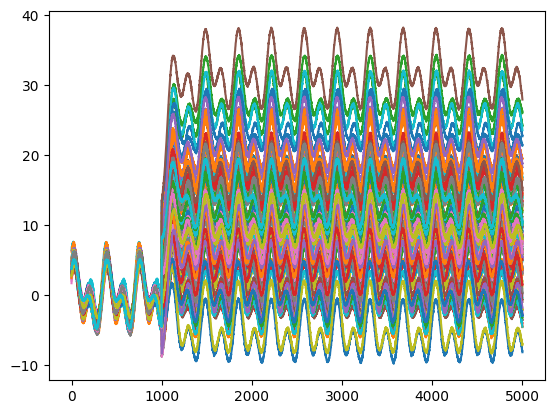

In [110]:
import matplotlib.pylab as plt

plt.plot(t,X)

##Run the PCA Analysis

The analysis will start by first scaling the original data matrix and then using the sklearn PCA package to perform the PCA for the first 4 components

In [111]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [112]:
scaler = StandardScaler()
scaled_array = scaler.fit_transform(X)

In [113]:
# ---------------------------------------------------------
# Perform PCA
# ---------------------------------------------------------
# Let's extract the top 4 principal components
pca = PCA(n_components=4)
pc_array = pca.fit_transform(scaled_array)

print(f"Principal components array shape: {pc_array.shape}")


Principal components array shape: (5000, 4)


##Accessing the Results

This section will print out the explained variance for each of the PCs and then plot the PCs

Variance explained by PC1: 83.87%
Variance explained by PC2: 14.11%
Variance explained by PC3: 0.65%
Variance explained by PC4: 0.54%


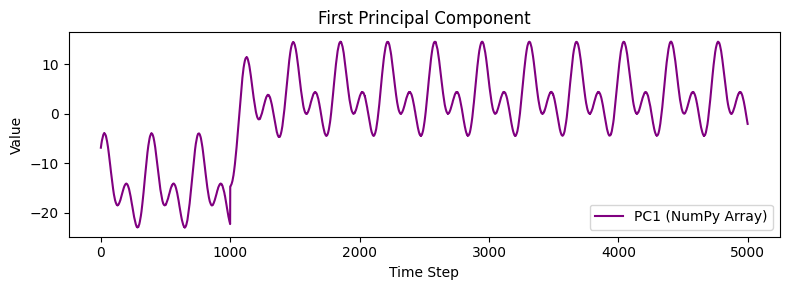

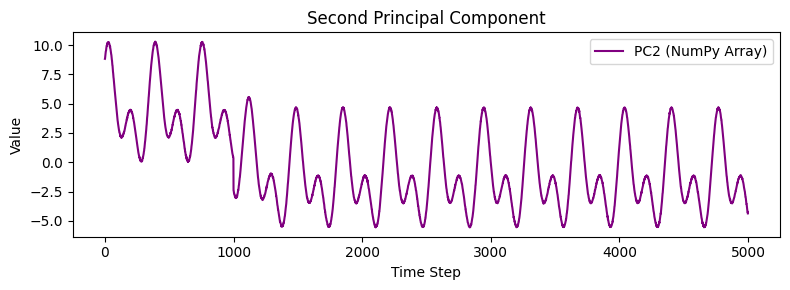

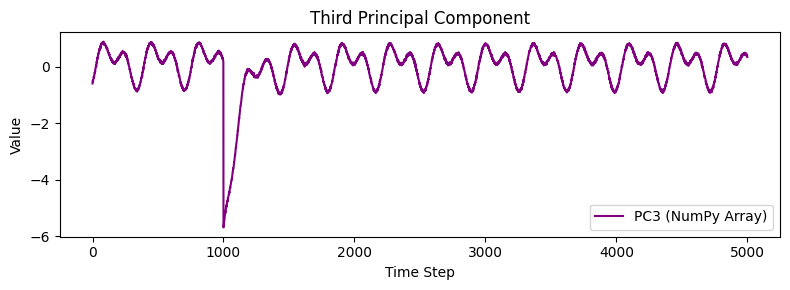

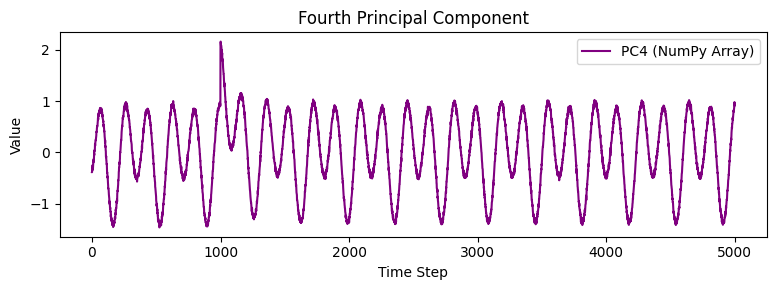

In [114]:
# ---------------------------------------------------------
# Accessing the Results
# ---------------------------------------------------------
# The explained variance tells you how much information each PC captures
explained_variance = pca.explained_variance_ratio_
print(f"Variance explained by PC1: {explained_variance[0]*100:.2f}%")
print(f"Variance explained by PC2: {explained_variance[1]*100:.2f}%")
print(f"Variance explained by PC3: {explained_variance[2]*100:.2f}%")
print(f"Variance explained by PC4: {explained_variance[3]*100:.2f}%")

# You can extract individual components via standard NumPy slicing
# Here, we grab all rows (time steps) for the first column (PC1)
pc1 = pc_array[:, 0]
pc2 = pc_array[:, 1]
pc3 = pc_array[:, 2]
pc4 = pc_array[:, 3]


plt.figure(figsize=(8, 3))
plt.plot(pc1, label='PC1 (NumPy Array)', color='purple')
plt.title('First Principal Component')
plt.xlabel('Time Step')
plt.ylabel('Value')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 3))
plt.plot(pc2, label='PC2 (NumPy Array)', color='purple')
plt.title('Second Principal Component')
plt.xlabel('Time Step')
plt.ylabel('Value')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 3))
plt.plot(pc3, label='PC3 (NumPy Array)', color='purple')
plt.title('Third Principal Component')
plt.xlabel('Time Step')
plt.ylabel('Value')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 3))
plt.plot(pc4, label='PC4 (NumPy Array)', color='purple')
plt.title('Fourth Principal Component')
plt.xlabel('Time Step')
plt.ylabel('Value')
plt.legend()
plt.tight_layout()
plt.show()

##Obtaining the Loading Values

Here, we will extract the loading values for each station and each of the 4 principal components

In [115]:
# Extract the loadings
loadings = pca.components_

print(f"Loadings array shape: {loadings.shape}")
# Output: Loadings array shape: (2, 5)
# Note: The shape is (n_components, n_features)

# 2. Transpose for easier reading
# It is usually easier to read if rows are your original variables
# and columns are your principal components.
loadings_transposed = loadings.T

print("\nLoading Values (Rows = Original Series, Cols = PC1, PC2, PC3, PC4):")
print(np.round(loadings_transposed, 3))

Loadings array shape: (4, 100)

Loading Values (Rows = Original Series, Cols = PC1, PC2, PC3, PC4):
[[ 0.107  0.006 -0.198  0.056]
 [ 0.107 -0.05  -0.002  0.043]
 [ 0.107 -0.044 -0.051  0.063]
 [ 0.105 -0.059 -0.115 -0.056]
 [ 0.107 -0.023 -0.06  -0.146]
 [ 0.106 -0.067 -0.001 -0.052]
 [ 0.106  0.049  0.148 -0.078]
 [ 0.107 -0.047 -0.067 -0.   ]
 [ 0.098  0.106  0.12   0.069]
 [ 0.105  0.051 -0.254  0.003]
 [ 0.105 -0.069  0.033  0.019]
 [ 0.056  0.222  0.067 -0.242]
 [ 0.105 -0.069 -0.02   0.087]
 [ 0.107 -0.018  0.045  0.103]
 [ 0.108 -0.028 -0.024  0.016]
 [ 0.108 -0.026 -0.064  0.088]
 [ 0.106 -0.06  -0.02  -0.094]
 [ 0.107 -0.037  0.069  0.008]
 [ 0.097  0.122  0.074 -0.083]
 [ 0.095  0.115  0.103 -0.077]
 [ 0.099 -0.106 -0.084  0.093]
 [ 0.106  0.06   0.033 -0.064]
 [ 0.1   -0.104 -0.035  0.075]
 [ 0.109  0.009 -0.017  0.052]
 [ 0.087  0.153  0.083  0.103]
 [ 0.107  0.044 -0.069  0.122]
 [ 0.102  0.092  0.03  -0.076]
 [ 0.1    0.091  0.013 -0.219]
 [ 0.106 -0.023 -0.214  0.02 ]
 

##Reconstruct the time series from the PCs and the loadings

In this step, we will multiply the loadings by the PCs to obtain a reconstruction of the original time series. We will only plot the first time series

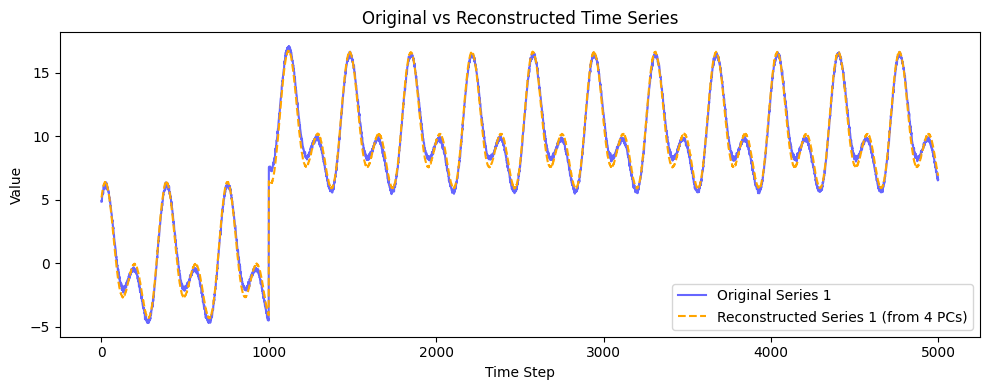

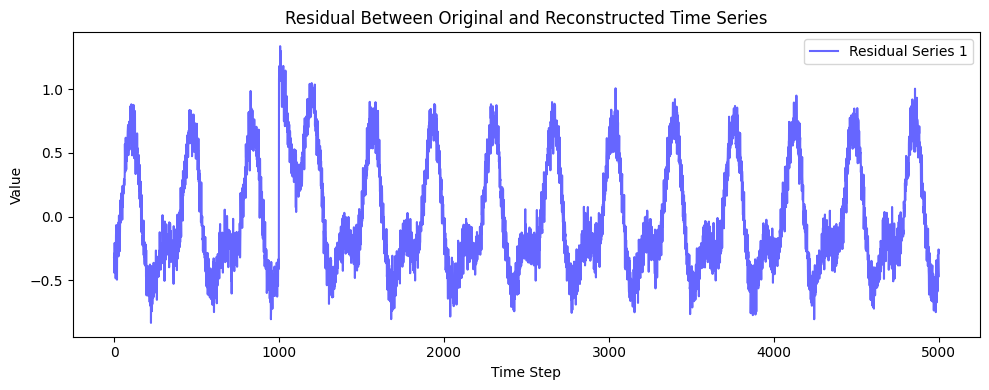

In [116]:
# =========================================================
# Method 1: The Manual Mathematical Way
# =========================================================
# 1. Multiply PCs by Loadings to get the reconstructed scaled data
reconstructed_scaled_manual = np.dot(pc_array, loadings)

# 2. Reverse the standardization to get the original scale
reconstructed_manual = scaler.inverse_transform(reconstructed_scaled_manual)

# =========================================================
# Method 2: The Scikit-Learn Shortcut
# =========================================================
# pca.inverse_transform does the exact same dot product under the hood
reconstructed_scaled_sklearn = pca.inverse_transform(pc_array)

# Reverse the standardization
reconstructed_sklearn = scaler.inverse_transform(reconstructed_scaled_sklearn)

# =========================================================
# Verify and Visualize
# =========================================================
# Let's plot the original Series 1 vs its Reconstruction
plt.figure(figsize=(10, 4))
plt.plot(X[:, 0], label='Original Series 1', color='blue', alpha=0.6)
plt.plot(reconstructed_manual[:, 0], label='Reconstructed Series 1 (from 4 PCs)',
         color='orange', linestyle='--')
plt.title('Original vs Reconstructed Time Series')
plt.xlabel('Time Step')
plt.ylabel('Value')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(X[:, 0]-reconstructed_manual[:, 0], label='Residual Series 1', color='blue', alpha=0.6)
plt.title('Residual Between Original and Reconstructed Time Series')
plt.xlabel('Time Step')
plt.ylabel('Value')
plt.legend()
plt.tight_layout()
plt.show()

##Plotting a biplot

For this example, it will look ridiculous, but this just shows how to do it. Since we have 100 time series, the biplot looks very muddied.

This will also plot the time series of the two PCs against each other. You will notice a gap in the path, which is at the time of the offset at 1000 time steps in.

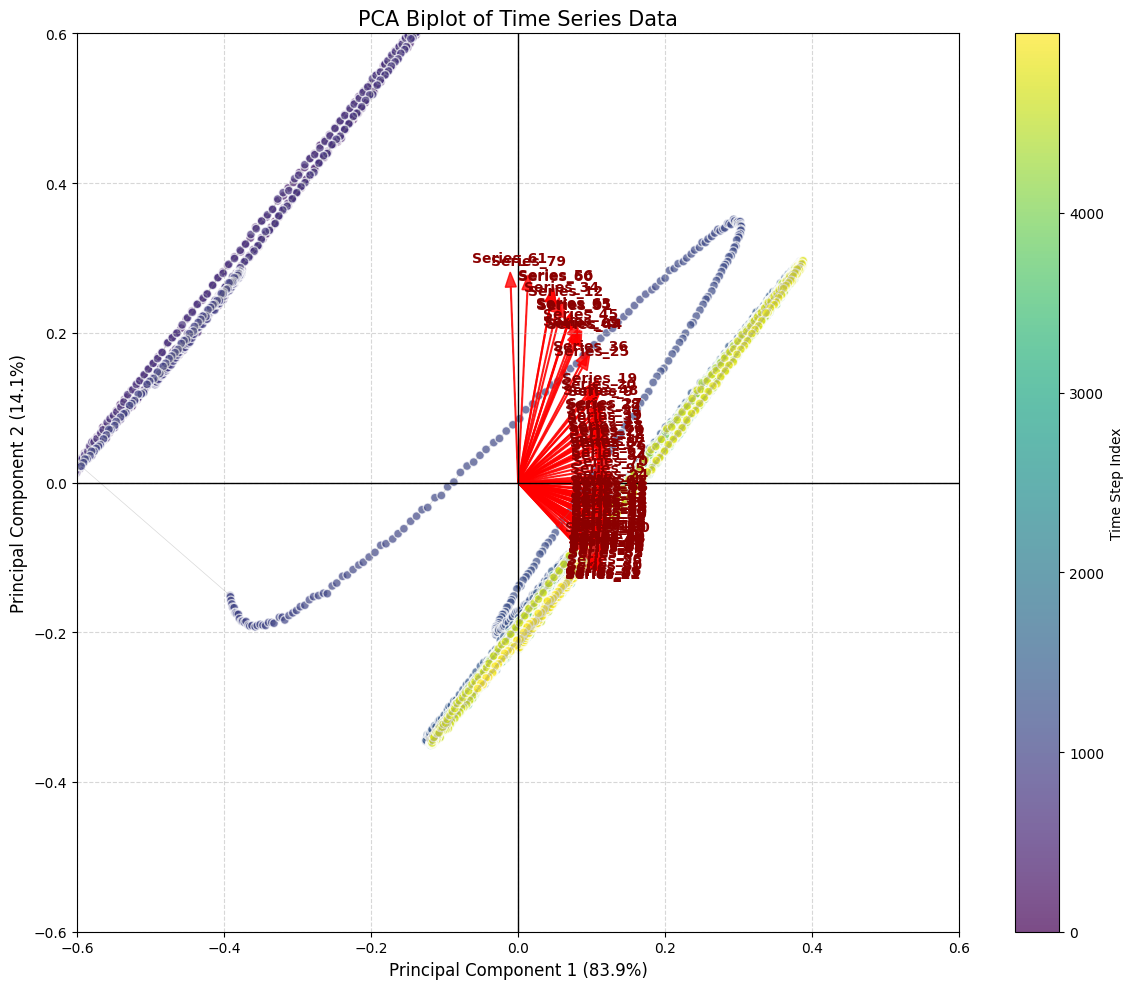

In [122]:
# =========================================================
# Define Custom Time Series Biplot Function
# =========================================================
def biplot(score, coeff, labels=None, pc_x=1, pc_y=2):
    """
    Generates a PCA biplot.
    Args:
        score: The PCA scores (pc_scores array).
        coeff: The PCA components (loadings.T).
        labels: List of feature names for the loading vectors.
        pc_x: Which PC to plot on the x-axis (default 1).
        pc_y: Which PC to plot on the y-axis (default 2).
    """
    xs = score[:, pc_x - 1] # Subtract 1 for 0-based indexing
    ys = score[:, pc_y - 1]

    n = coeff.shape[0] # Number of original variables

    # Calculate a scaling factor so the loading vectors are visible
    # alongside the scores. (We scale them to match the score distribution)
    scalex = 1.0/(xs.max() - xs.min())
    scaley = 1.0/(ys.max() - ys.min())

    plt.figure(figsize=(12, 10))

    # --- Plotting Scores ---
    # We use a colormap (cm.viridis) based on the index (0-199)
    # to show the time progression.
    time_indices = np.arange(time_steps)
    scatter = plt.scatter(xs * scalex, ys * scaley, c=time_indices,
                          cmap='viridis', alpha=0.7, edgecolor='w', s=40)

    # Optional: Connect the points over time to visualize the path
    plt.plot(xs * scalex, ys * scaley, color='gray', alpha=0.3, linewidth=0.5)

    # Add a colorbar to indicate time
    cbar = plt.colorbar(scatter)
    cbar.set_label('Time Step Index')

    # --- Plotting Loading Vectors ---
    for i in range(n):
        plt.arrow(0, 0, coeff[i, pc_x - 1], coeff[i, pc_y - 1],
                  color='red', alpha=0.8, head_width=0.015, head_length=0.02)
        if labels is None:
            plt.text(coeff[i, pc_x - 1] * 1.15, coeff[i, pc_y - 1] * 1.15,
                     "Var"+str(i+1), color='darkred', ha='center', va='center')
        else:
            plt.text(coeff[i, pc_x - 1] * 1.15, coeff[i, pc_y - 1] * 1.15,
                     labels[i], color='darkred', ha='center', va='center', weight='bold')

    # Formatting
    var_exp = pca.explained_variance_ratio_ * 100
    plt.xlabel(f"Principal Component {pc_x} ({var_exp[pc_x-1]:.1f}%)", fontsize=12)
    plt.ylabel(f"Principal Component {pc_y} ({var_exp[pc_y-1]:.1f}%)", fontsize=12)
    plt.title("PCA Biplot of Time Series Data", fontsize=15)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.xlim(-0.6, 0.6) # Adjust limits as needed based on data
    plt.ylim(-0.6, 0.6)
    plt.axhline(0, color='black',linewidth=1)
    plt.axvline(0, color='black',linewidth=1)
    plt.tight_layout()
    plt.show()

# =========================================================
# 3. Call the Biplot Function
# =========================================================
# Pass the scores and the TRANSPOSED loadings (variables as rows)
pc_scores = pca.fit_transform(scaled_array)
loadings = pca.components_
feature_names = [f'Series_{i+1}' for i in range(n)]
biplot(pc_scores, loadings.T, labels=feature_names)